# 醫療詐欺偵測：

保留 4 種模型：Logistic Regression、Random Forest、SVM、PCA + Logistic Regression，並整合特徵分析與最終圖表。

讀取資料中...
建構 Mega DataFrames...
進行 PCA 2D 視覺化...


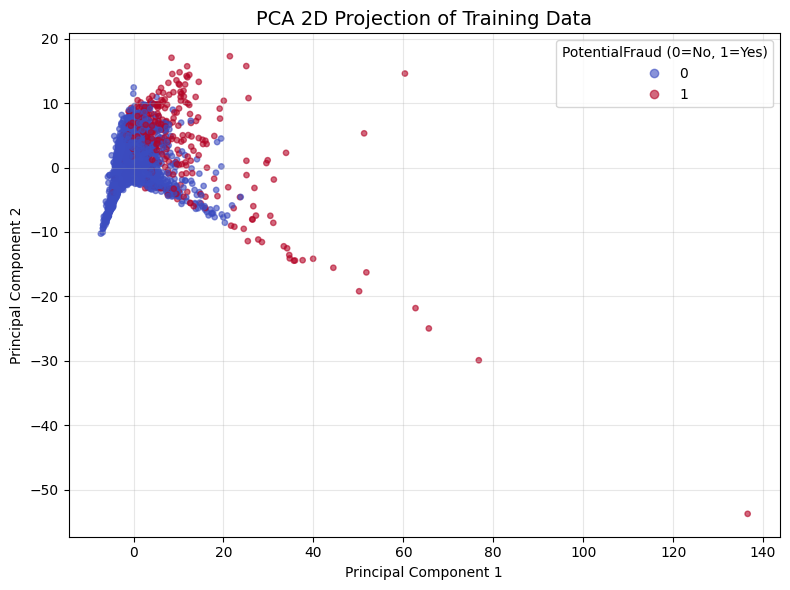

訓練 Logistic Regression...
訓練 Random Forest...
訓練 SVM...
訓練 PCA + Logistic Regression...
產生視覺化圖表...


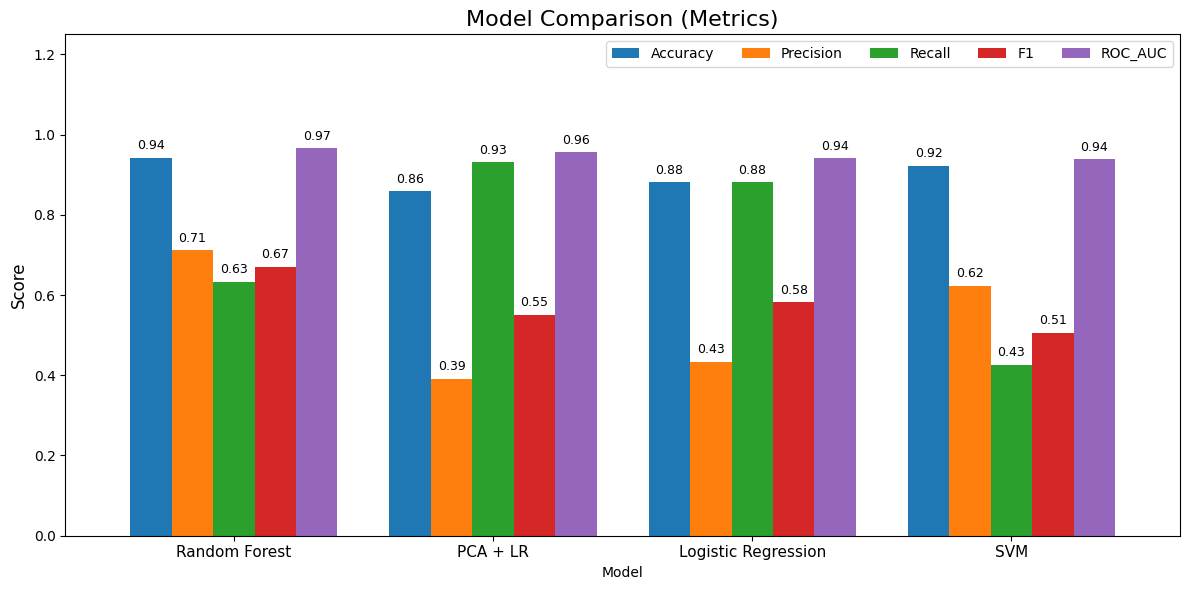

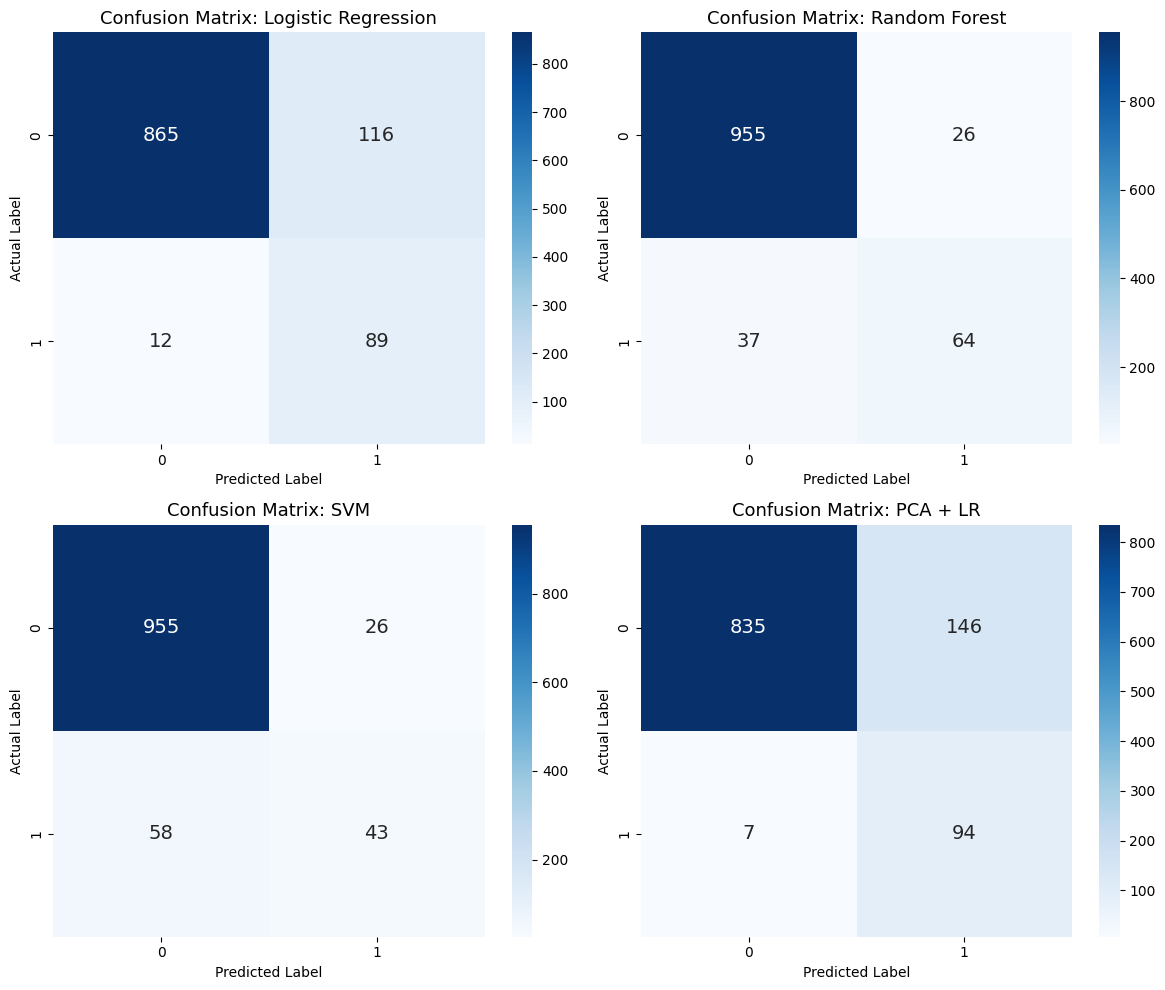

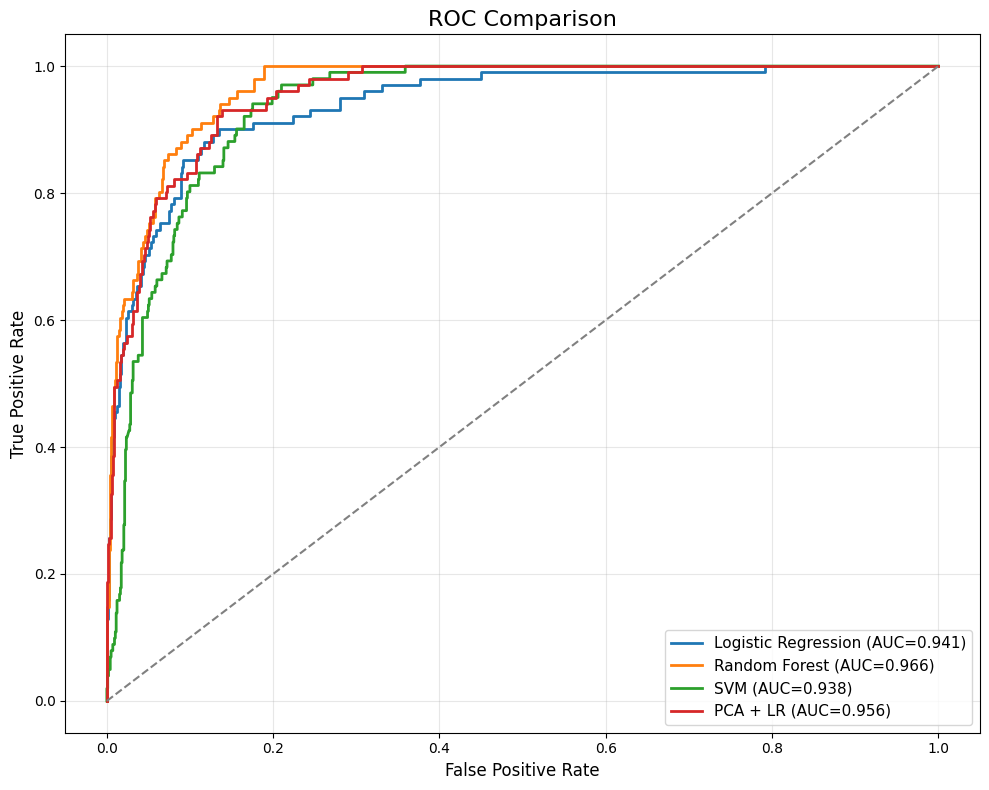

進行最終全量資料訓練並匯出 Submission...
[Logistic Regression] 預測已輸出至 submission_logistic_regression.csv
[Random Forest] 預測已輸出至 submission_random_forest.csv
[SVM] 預測已輸出至 submission_svm.csv
[PCA LR] 預測已輸出至 submission_pca_lr.csv

🎉 全部流程執行完畢！目前僅保留 Logistic Regression、Random Forest、SVM、PCA + LR。


In [ ]:
import os
import warnings
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.svm import SVC

# ==========================================
# 1. 基本設定與初始化
# ==========================================
SEED = 42
np.random.seed(SEED)

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ==========================================
# 2. 工具函式
# ==========================================
def find_file(filename: str) -> str:
    """到常見資料夾尋找檔案，避免 Notebook 因路徑不同而讀不到。"""
    search_dirs = [
        ".",
        "./data",
        "/mnt/data",
        "/content",
        "/content/data",
        "/content/drive/MyDrive",
        "/content/drive/MyDrive/data",
    ]
    for d in search_dirs:
        p = Path(d) / filename
        if p.exists():
            return str(p)
    raise FileNotFoundError(f"找不到檔案：{filename}，請確認資料已放在目前目錄、data、/mnt/data 或 Colab Drive。")

def normalize_yes_no(series: pd.Series) -> pd.Series:
    return (
        series.astype(str)
        .str.strip()
        .str.upper()
        .map({"YES": 1, "NO": 0, "Y": 1, "N": 0, "1": 1, "0": 0})
    )

def preprocess_beneficiary(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # 常見二元欄位 1/2 -> 1/0
    for col in df.columns:
        if df[col].dtype != "object":
            vals = set(pd.Series(df[col]).dropna().unique())
            if len(vals) > 0 and vals.issubset({1, 2}):
                df[col] = df[col].replace({2: 0})

    if "RenalDiseaseIndicator" in df.columns:
        df["RenalDiseaseIndicator"] = (
            df["RenalDiseaseIndicator"]
            .astype(str)
            .str.strip()
            .str.upper()
            .replace({"Y": 1, "N": 0})
        )
        df["RenalDiseaseIndicator"] = pd.to_numeric(df["RenalDiseaseIndicator"], errors="coerce")

    for col in ["DOB", "DOD"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")

    if "DOD" in df.columns:
        df["WhetherDead"] = np.where(df["DOD"].isna(), 0, 1)
    else:
        df["WhetherDead"] = 0

    if "DOB" in df.columns:
        ref_date = pd.Timestamp("2009-12-01")
        end_date = df["DOD"].fillna(ref_date) if "DOD" in df.columns else ref_date
        df["Age"] = ((end_date - df["DOB"]).dt.days / 365.25).clip(lower=0)
    else:
        df["Age"] = np.nan

    numeric_candidates = [
        "Gender", "Race", "State", "County",
        "NoOfMonths_PartACov", "NoOfMonths_PartBCov",
        "IPAnnualReimbursementAmt", "IPAnnualDeductibleAmt",
        "OPAnnualReimbursementAmt", "OPAnnualDeductibleAmt"
    ]
    for col in numeric_candidates:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df

def preprocess_claims(df: pd.DataFrame, is_inpatient: int) -> pd.DataFrame:
    out = df.copy()

    for col in ["AdmissionDt", "DischargeDt", "ClaimStartDt", "ClaimEndDt"]:
        if col in out.columns:
            out[col] = pd.to_datetime(out[col], errors="coerce")

    if is_inpatient == 1:
        if {"AdmissionDt", "DischargeDt"}.issubset(out.columns):
            out["StayDays"] = (out["DischargeDt"] - out["AdmissionDt"]).dt.days
        else:
            out["StayDays"] = np.nan
    else:
        if {"ClaimStartDt", "ClaimEndDt"}.issubset(out.columns):
            out["StayDays"] = (out["ClaimEndDt"] - out["ClaimStartDt"]).dt.days
        else:
            out["StayDays"] = np.nan

    out["StayDays"] = out["StayDays"].fillna(0).clip(lower=0)
    out["IsInpatient"] = is_inpatient

    money_cols = [
        "InscClaimAmtReimbursed", "DeductibleAmtPaid",
        "IPAnnualReimbursementAmt", "IPAnnualDeductibleAmt",
        "OPAnnualReimbursementAmt", "OPAnnualDeductibleAmt"
    ]
    for col in money_cols:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")

    diag_cols = [c for c in out.columns if c.startswith("ClmDiagnosisCode")]
    proc_cols = [c for c in out.columns if c.startswith("ClmProcedureCode")]
    out["DiagnosisCodeCount"] = out[diag_cols].notna().sum(axis=1) if diag_cols else 0
    out["ProcedureCodeCount"] = out[proc_cols].notna().sum(axis=1) if proc_cols else 0

    return out

def build_mega(label_df, bene_df, inpatient_df, outpatient_df, provider_df=None, fit_mode=True):
    bene = preprocess_beneficiary(bene_df)
    ip = preprocess_claims(inpatient_df, 1)
    op = preprocess_claims(outpatient_df, 0)

    ip_full = ip.merge(bene, on="BeneID", how="left")
    op_full = op.merge(bene, on="BeneID", how="left")

    all_cols = sorted(set(ip_full.columns).union(set(op_full.columns)))
    ip_full = ip_full.reindex(columns=all_cols)
    op_full = op_full.reindex(columns=all_cols)

    claims = pd.concat([ip_full, op_full], ignore_index=True)

    numeric_cols = claims.select_dtypes(include=[np.number, "bool"]).columns.tolist()
    agg_map = {c: ["mean", "sum", "max", "std"] for c in numeric_cols if c != "PotentialFraud"}

    provider_num = claims.groupby("Provider").agg(agg_map)
    provider_num.columns = [f"{c}_{s}" for c, s in provider_num.columns]
    provider_num = provider_num.reset_index()

    extra_agg = {
        "ClaimCount": ("ClaimID", "count") if "ClaimID" in claims.columns else ("BeneID", "count"),
        "UniqueBene": ("BeneID", "nunique")
    }
    for col in ["AttendingPhysician", "OperatingPhysician", "OtherPhysician"]:
        if col in claims.columns:
            extra_agg[f"Unique_{col}"] = (col, "nunique")

    provider_extra = claims.groupby("Provider").agg(**extra_agg).reset_index()
    mega = provider_num.merge(provider_extra, on="Provider", how="left")

    if provider_df is not None and "Provider" in provider_df.columns:
        mega = mega.merge(provider_df[["Provider"]], on="Provider", how="right")

    if fit_mode and label_df is not None:
        label = label_df.copy()
        label["PotentialFraud"] = normalize_yes_no(label["PotentialFraud"])
        mega = mega.merge(label[["Provider", "PotentialFraud"]], on="Provider", how="inner")

    mega = mega.replace([np.inf, -np.inf], np.nan)
    return mega

def metric_row(name, y_true, y_pred, y_prob):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_prob),
    }

def train_and_export(model, model_name, X_train_data, y_train_data, X_test_data, provider_series):
    model.fit(X_train_data, y_train_data)
    if hasattr(model, "predict_proba"):
        test_prob = model.predict_proba(X_test_data)[:, 1]
    else:
        # 這份 Notebook 目前保留的模型都有 predict_proba，保留備援寫法
        raw_score = model.decision_function(X_test_data)
        test_prob = (raw_score - raw_score.min()) / (raw_score.max() - raw_score.min() + 1e-9)

    sub = pd.DataFrame({
        "Provider": provider_series,
        "FraudProbability": test_prob,
        "PotentialFraud": np.where(test_prob >= 0.5, "Yes", "No")
    })
    filename = f"submission_{model_name.replace(' + ', '_').replace(' ', '_').lower()}.csv"
    sub.to_csv(os.path.join(OUTPUT_DIR, filename), index=False)
    print(f"[{model_name}] 預測已輸出至 {filename}")

# ==========================================
# 3. 讀取資料
# ==========================================
print("讀取資料中...")
train_label = pd.read_csv(find_file("ta1.csv"), on_bad_lines='skip')
train_bene = pd.read_csv(find_file("ta1b.csv"), on_bad_lines='skip')
train_in = pd.read_csv(find_file("ta1in.csv"), on_bad_lines='skip')
train_out = pd.read_csv(find_file("ta1out.csv"), on_bad_lines='skip')

test_provider = pd.read_csv(find_file("ta2.csv"), on_bad_lines='skip')
test_bene = pd.read_csv(find_file("ta2b.csv"), on_bad_lines='skip')
test_in = pd.read_csv(find_file("ta2in.csv"), on_bad_lines='skip')
test_out = pd.read_csv(find_file("ta2out.csv"), on_bad_lines='skip')

print("建構 Mega DataFrames...")
mega_train = build_mega(train_label, train_bene, train_in, train_out, None, True)
mega_test = build_mega(None, test_bene, test_in, test_out, test_provider, False)

if "PotentialFraud" not in mega_train.columns:
    raise ValueError("mega_train 缺少 PotentialFraud 欄位，請檢查 ta1.csv 是否正確。")

target_col = "PotentialFraud"
feature_cols = [c for c in mega_train.columns if c not in ["Provider", target_col]]

X = mega_train[feature_cols].copy()
y = mega_train[target_col].astype(int)

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Logistic / SVM / PCA 共用前處理
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), X_train.columns.tolist())
])

X_train_scaled = preprocessor.fit_transform(X_train)
X_valid_scaled = preprocessor.transform(X_valid)

# Random Forest 使用僅補值版本
rf_imputer = SimpleImputer(strategy="median")
X_train_rf = rf_imputer.fit_transform(X_train)
X_valid_rf = rf_imputer.transform(X_valid)

# ==========================================
# 4. PCA 2D 視覺化
# ==========================================
print("進行 PCA 2D 視覺化...")
pca_2d = PCA(n_components=2, random_state=SEED)
X_train_2d = pca_2d.fit_transform(X_train_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, cmap="coolwarm", alpha=0.6, s=15)
plt.title("PCA 2D Projection of Training Data", fontsize=14)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(*scatter.legend_elements(), title="PotentialFraud (0=No, 1=Yes)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ==========================================
# 5. 模型訓練與評估（只保留 4 種）
# ==========================================
results = []
roc_data = {}
conf_matrices = {}

# (1) Logistic Regression
print("訓練 Logistic Regression...")
lr = LogisticRegression(max_iter=5000, class_weight="balanced", random_state=SEED)
lr.fit(X_train_scaled, y_train)
lr_prob = lr.predict_proba(X_valid_scaled)[:, 1]
lr_pred = (lr_prob >= 0.5).astype(int)
results.append(metric_row("Logistic Regression", y_valid, lr_pred, lr_prob))
roc_data["Logistic Regression"] = roc_curve(y_valid, lr_prob)
conf_matrices["Logistic Regression"] = confusion_matrix(y_valid, lr_pred)

# (2) Random Forest
print("訓練 Random Forest...")
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=16,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1
)
rf.fit(X_train_rf, y_train)
rf_prob = rf.predict_proba(X_valid_rf)[:, 1]
rf_pred = (rf_prob >= 0.5).astype(int)
results.append(metric_row("Random Forest", y_valid, rf_pred, rf_prob))
roc_data["Random Forest"] = roc_curve(y_valid, rf_prob)
conf_matrices["Random Forest"] = confusion_matrix(y_valid, rf_pred)

# (3) SVM
print("訓練 SVM...")
svm = SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=SEED)
svm.fit(X_train_scaled, y_train)
svm_prob = svm.predict_proba(X_valid_scaled)[:, 1]
svm_pred = (svm_prob >= 0.5).astype(int)
results.append(metric_row("SVM", y_valid, svm_pred, svm_prob))
roc_data["SVM"] = roc_curve(y_valid, svm_prob)
conf_matrices["SVM"] = confusion_matrix(y_valid, svm_pred)

# (4) PCA + Logistic Regression
print("訓練 PCA + Logistic Regression...")
pca = PCA(n_components=0.95, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_scaled)
X_valid_pca = pca.transform(X_valid_scaled)

pca_lr = LogisticRegression(max_iter=5000, class_weight="balanced", random_state=SEED)
pca_lr.fit(X_train_pca, y_train)
pca_prob = pca_lr.predict_proba(X_valid_pca)[:, 1]
pca_pred = (pca_prob >= 0.5).astype(int)
results.append(metric_row("PCA + LR", y_valid, pca_pred, pca_prob))
roc_data["PCA + LR"] = roc_curve(y_valid, pca_prob)
conf_matrices["PCA + LR"] = confusion_matrix(y_valid, pca_pred)

# ==========================================
# 6. 成果評估與視覺化
# ==========================================
print("產生視覺化圖表...")
results_df = pd.DataFrame(results).sort_values("ROC_AUC", ascending=False)
results_df.to_csv(os.path.join(OUTPUT_DIR, "model_comparison.csv"), index=False)

plot_df = results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]]
ax = plot_df.plot(kind="bar", figsize=(12, 6), width=0.8)
ax.set_title("Model Comparison (Metrics)", fontsize=16)
ax.set_ylabel("Score", fontsize=12)
ax.set_ylim(0, 1.25)
plt.xticks(rotation=0, fontsize=11)

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(
            f"{p.get_height():.2f}",
            (p.get_x() + p.get_width() / 2.0, p.get_height()),
            ha="center", va="bottom", xytext=(0, 4),
            textcoords="offset points", fontsize=9
        )

plt.legend(loc="upper right", ncol=5)
plt.tight_layout()
plt.show()

# 6-1. 混淆矩陣
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (model_name, cm) in enumerate(conf_matrices.items()):
    sns.heatmap(cm, annot=True, fmt="g", cmap="Blues", ax=axes[i], annot_kws={"size": 14})
    axes[i].set_title(f"Confusion Matrix: {model_name}", fontsize=13)
    axes[i].set_xlabel("Predicted Label")
    axes[i].set_ylabel("Actual Label")

plt.tight_layout()
plt.show()

# 6-2. ROC 曲線
plt.figure(figsize=(10, 8))
for model_name, (fpr, tpr, _) in roc_data.items():
    auc_val = results_df.loc[results_df["Model"] == model_name, "ROC_AUC"].iloc[0]
    plt.plot(fpr, tpr, lw=2, label=f"{model_name} (AUC={auc_val:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Comparison", fontsize=16)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ==========================================
# 7. 全量資料訓練與輸出測試集預測
# ==========================================
print("進行最終全量資料訓練並匯出 Submission...")
X_full = mega_train[feature_cols].copy()
y_full = mega_train[target_col].astype(int)

X_test = mega_test.copy()
for col in feature_cols:
    if col not in X_test.columns:
        X_test[col] = np.nan
X_test = X_test[feature_cols]

# Logistic / SVM / PCA 使用標準化版本
X_full_scaled = preprocessor.fit_transform(X_full)
X_test_scaled = preprocessor.transform(X_test)

# Random Forest 使用僅補值版本
X_full_rf = rf_imputer.fit_transform(X_full)
X_test_rf = rf_imputer.transform(X_test)

# Logistic Regression Submission
train_and_export(
    LogisticRegression(max_iter=5000, class_weight="balanced", random_state=SEED),
    "Logistic Regression",
    X_full_scaled, y_full, X_test_scaled, mega_test["Provider"]
)

# Random Forest Submission
train_and_export(
    RandomForestClassifier(
        n_estimators=500,
        max_depth=16,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1
    ),
    "Random Forest",
    X_full_rf, y_full, X_test_rf, mega_test["Provider"]
)

# SVM Submission
train_and_export(
    SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=SEED),
    "SVM",
    X_full_scaled, y_full, X_test_scaled, mega_test["Provider"]
)

# PCA + LR Submission
pca_full = PCA(n_components=0.95, random_state=SEED)
X_full_pca = pca_full.fit_transform(X_full_scaled)
X_test_pca = pca_full.transform(X_test_scaled)
train_and_export(
    LogisticRegression(max_iter=5000, class_weight="balanced", random_state=SEED),
    "PCA LR",
    X_full_pca, y_full, X_test_pca, mega_test["Provider"]
)

print("\n🎉 全部流程執行完畢！目前僅保留 Logistic Regression、Random Forest、SVM、PCA + LR。")

In [ ]:

# ==========================================
# 8. 匯出整理後資料
# ==========================================
mega_test_output_path = os.path.join(OUTPUT_DIR, "processed_mega_test.csv")
mega_train_output_path = os.path.join(OUTPUT_DIR, "processed_mega_train.csv")

mega_test.to_csv(mega_test_output_path, index=False)
mega_train.to_csv(mega_train_output_path, index=False)

print(f"整理後的測試資料集已儲存至：{mega_test_output_path}")
print(f"整理後的訓練資料集已儲存至：{mega_train_output_path}")


In [ ]:

# ==========================================
# 9. 各模型 Top 5 特徵重要度
# ==========================================
print("=" * 60)
print("🏆 各模型 Top 5 重要特徵排行榜")
print("=" * 60)

feature_names_scaled = preprocessor.get_feature_names_out()

# Logistic Regression
lr_imp = np.abs(lr.coef_[0])
lr_top5 = pd.Series(lr_imp, index=feature_names_scaled).nlargest(5)
print("\n[1] Logistic Regression (權重絕對值):")
for feat, val in lr_top5.items():
    print(f"  - {feat}: {val:.4f}")

# Random Forest
rf_imp = rf.feature_importances_
rf_feature_names = feature_cols if len(rf_imp) == len(feature_cols) else feature_names_scaled
rf_top5 = pd.Series(rf_imp, index=rf_feature_names).nlargest(5)
print("\n[2] Random Forest (Gini Importance):")
for feat, val in rf_top5.items():
    print(f"  - {feat}: {val:.4f}")

# SVM（RBF 無正式 coef_，以支持向量平均影響程度近似）
support_feature_proxy = np.abs(X_train_scaled[svm.support_]).mean(axis=0)
svm_top5 = pd.Series(np.ravel(support_feature_proxy), index=feature_names_scaled).nlargest(5)
print("\n[3] SVM (以支持向量平均影響程度近似):")
for feat, val in svm_top5.items():
    print(f"  - {feat}: {val:.4f}")

# PCA + Logistic Regression（投射回原始特徵）
pca_lr_imp = np.abs(np.dot(pca_lr.coef_[0], pca.components_))
pca_lr_top5 = pd.Series(pca_lr_imp, index=feature_names_scaled).nlargest(5)
print("\n[4] PCA + Logistic Regression (投射回原始特徵):")
for feat, val in pca_lr_top5.items():
    print(f"  - {feat}: {val:.4f}")

feature_importance_summary = pd.DataFrame({
    "Logistic Regression": lr_top5,
    "Random Forest": rf_top5,
    "SVM": svm_top5,
    "PCA + LR": pca_lr_top5
})
feature_importance_summary.to_csv(
    os.path.join(OUTPUT_DIR, "feature_importance_summary.csv"),
    encoding="utf-8-sig"
)
print(f"\n特徵重要度摘要已輸出到：{os.path.join(OUTPUT_DIR, 'feature_importance_summary.csv')}")


🏆 各模型 Top 5 重要特徵排行榜

[1] Logistic Regression (權重絕對值):
  - num__ChronicCond_Alzheimer_max: 1.5207
  - num__ChronicCond_ObstrPulmonary_sum: 1.3662
  - num__StayDays_max: 1.2142
  - num__InscClaimAmtReimbursed_sum: 1.1547
  - num__DiagnosisCodeCount_max: 1.1484

[2] Random Forest (Gini Importance):
  - num__InscClaimAmtReimbursed_sum: 0.0746
  - num__StayDays_max: 0.0647
  - num__DeductibleAmtPaid_sum: 0.0452
  - num__ClmProcedureCode_1_sum: 0.0448
  - num__InscClaimAmtReimbursed_max: 0.0339

[3] SVM (以支持向量平均影響程度近似):
  - num__IsInpatient_max: 1.1261
  - num__DeductibleAmtPaid_max: 1.1065
  - num__IsInpatient_std: 1.0698
  - num__DeductibleAmtPaid_std: 1.0678
  - num__ProcedureCodeCount_max: 1.0524

[4] PCA + Logistic Regression (投射回原始特徵):
  - num__ChronicCond_IschemicHeart_max: 0.6797
  - num__ChronicCond_Heartfailure_max: 0.5290
  - num__ChronicCond_KidneyDisease_mean: 0.4023
  - num__ChronicCond_Heartfailure_mean: 0.3575
  - num__ChronicCond_Diabetes_max: 0.3325

特徵重要度摘要已輸出到：outputs/fea

繪製各模型 Top 5 重要特徵圖表...


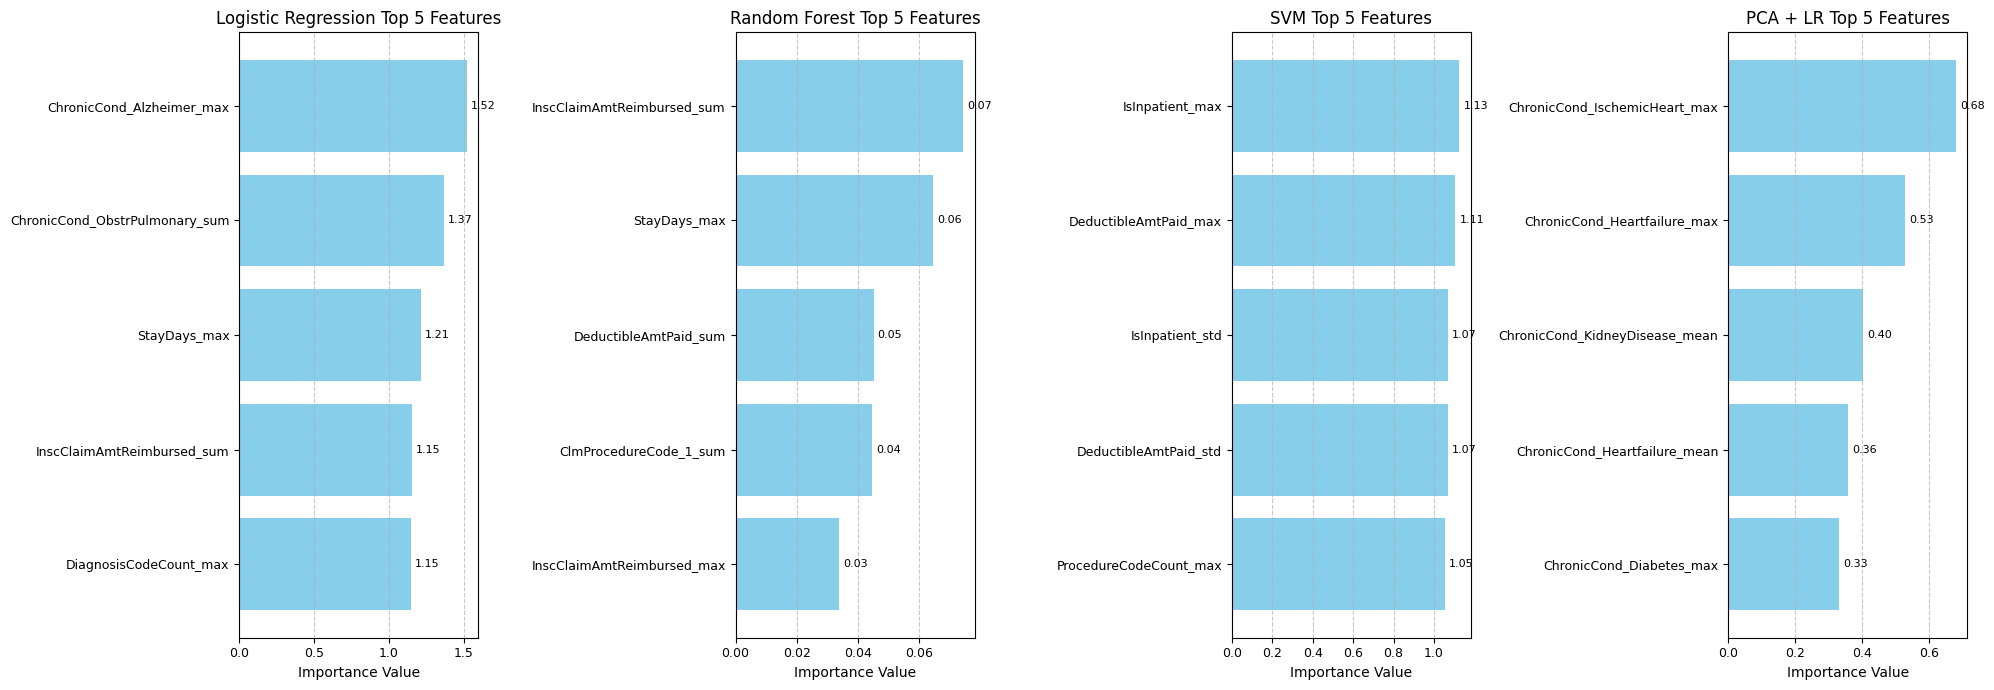

各模型 Top 5 特徵重要度圖表已輸出至：outputs/top5_feature_importance_charts.png


<Figure size 640x480 with 0 Axes>

In [ ]:
print("繪製各模型 Top 5 重要特徵圖表...")

# 假設 feature_importance_summary 已經在之前的步驟中生成
# 如果沒有，需要重新執行生成 feature_importance_summary 的代碼
# feature_importance_summary = pd.DataFrame(...)

num_models = len(feature_importance_summary.columns)
fig, axes = plt.subplots(1, num_models, figsize=(5 * num_models, 7))

# 如果只有一個模型，axes 會是一個 AxesSubplot 對象，而不是數組
if num_models == 1:
    axes = [axes]

for i, (model_name, series) in enumerate(feature_importance_summary.items()):
    ax = axes[i]
    # 移除 NaN 值並排序
    plot_data = series.dropna().sort_values(ascending=True)
    if not plot_data.empty:
        bars = ax.barh(plot_data.index, plot_data.values, color='skyblue')
        ax.set_title(f'{model_name} Top 5 Features', fontsize=12)
        ax.set_xlabel('Importance Value', fontsize=10)
        # 格式化特徵名稱，移除 'num__' 前綴
        ax.set_yticklabels([label.replace('num__', '') for label in plot_data.index], fontsize=9)
        ax.tick_params(axis='x', labelsize=9)
        ax.grid(axis='x', linestyle='--', alpha=0.7)

        # 在每個條形圖上添加數值標籤
        for bar in bars:
            ax.annotate(f'{bar.get_width():.2f}',
                        xy=(bar.get_width(), bar.get_y() + bar.get_height() / 2),
                        xytext=(3, 0),  # 3 points offset from the bar
                        textcoords="offset points",
                        ha='left', va='center', fontsize=8)
    else:
        ax.set_title(f'{model_name} Top 5 Features', fontsize=12)
        ax.text(0.5, 0.5, 'No features found', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)

plt.tight_layout()
plt.show()

output_chart_path = os.path.join(OUTPUT_DIR, "top5_feature_importance_charts.png")
plt.savefig(output_chart_path, dpi=300, bbox_inches="tight")
print(f"各模型 Top 5 特徵重要度圖表已輸出至：{output_chart_path}")

In [ ]:

# ==========================================
# 10. 共同特徵與 Top 10 平均重要度
# ==========================================
from collections import Counter

all_features_list = (
    list(lr_top5.index) +
    list(rf_top5.index) +
    list(svm_top5.index) +
    list(pca_lr_top5.index)
)
feature_count = Counter(all_features_list)

rows = []
for feat, count in feature_count.items():
    lr_val = lr_top5.get(feat, 0)
    rf_val = rf_top5.get(feat, 0)
    svm_val = svm_top5.get(feat, 0)
    pca_val = pca_lr_top5.get(feat, 0)
    avg_imp = np.mean([lr_val, rf_val, svm_val, pca_val])

    rows.append({
        "Feature": feat,
        "Model_Count": count,
        "Logistic Regression": lr_val,
        "Random Forest": rf_val,
        "SVM": svm_val,
        "PCA + LR": pca_val,
        "Avg_Importance": avg_imp
    })

feature_overlap_df = pd.DataFrame(rows).sort_values(
    by=["Model_Count", "Avg_Importance"],
    ascending=[False, False]
)

feature_overlap_df.to_csv(
    os.path.join(OUTPUT_DIR, "feature_overlap_summary.csv"),
    index=False,
    encoding="utf-8-sig"
)

# 至少出現在 2 個模型中的特徵
top10_df = feature_overlap_df[feature_overlap_df["Model_Count"] >= 2].copy()
top10_df = top10_df.head(10)

print("Top 10 共同重要特徵（至少出現在 2 個模型）：")
print(top10_df[["Feature", "Model_Count", "Avg_Importance"]])

top10_df.to_csv(
    os.path.join(OUTPUT_DIR, "final_top10_common_features.csv"),
    index=False,
    encoding="utf-8-sig"
)


Top 10 共同重要特徵（至少出現在 2 個模型）：
                           Feature  Model_Count  Avg_Importance
2                num__StayDays_max            2        0.319722
3  num__InscClaimAmtReimbursed_sum            2        0.307320


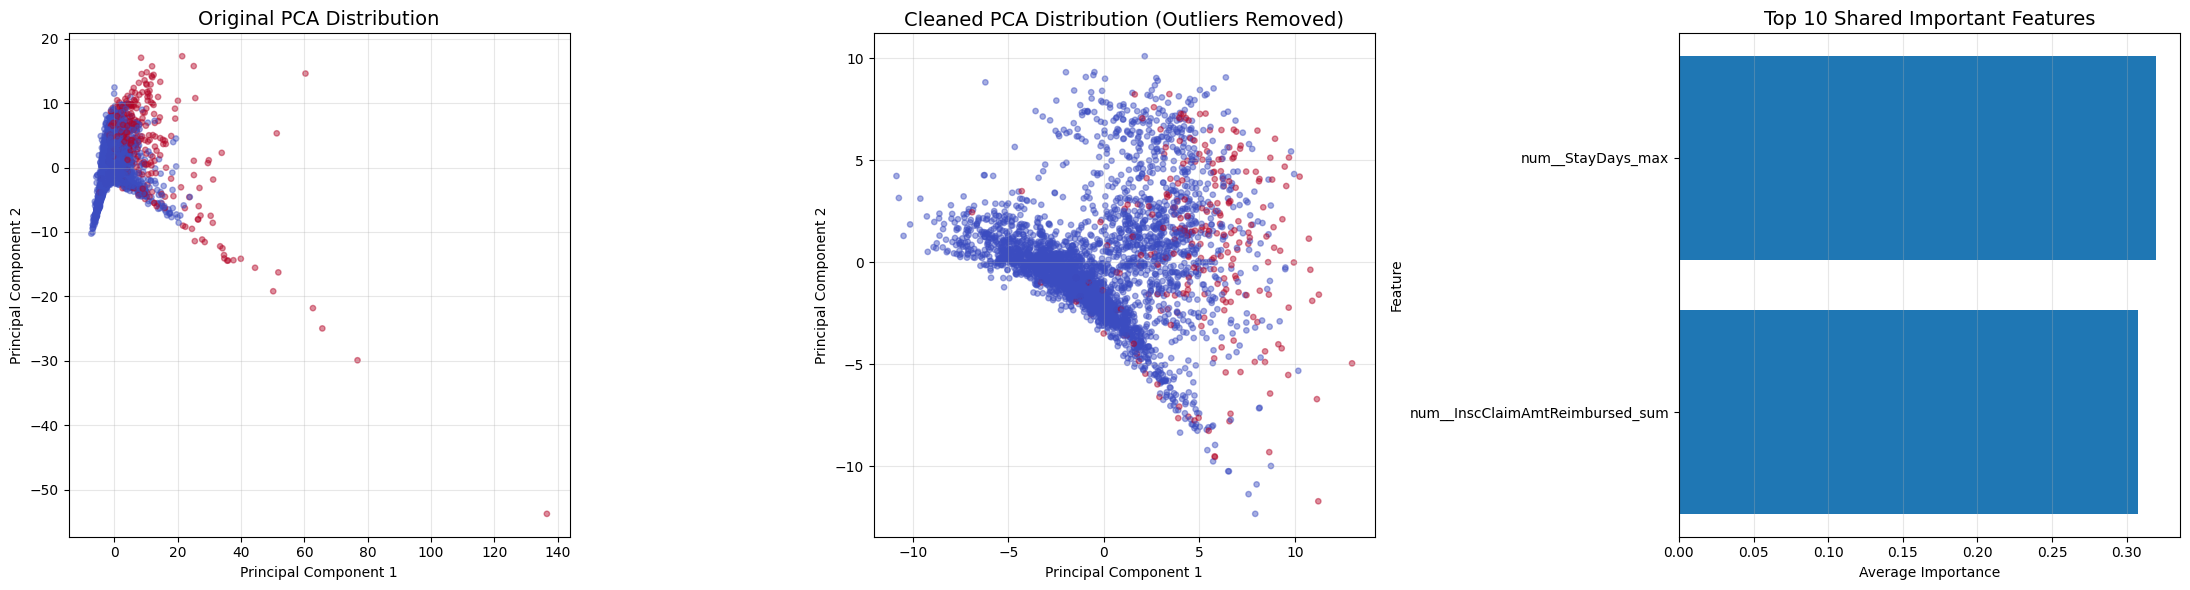

原始資料筆數： 4328
清理後資料筆數： 3556
Top10 共同特徵表已輸出：outputs/final_top10_common_features.csv
最終三圖已輸出：outputs/final_report_3plots.png


In [ ]:

# ==========================================
# 11. 最終圖表版：原始 PCA、修正版 PCA、Top 10 共同特徵
# ==========================================
from scipy.stats import zscore

# 原始 PCA
pca_raw = PCA(n_components=2, random_state=SEED)
X_pca_raw = pca_raw.fit_transform(X_train_scaled)

# 修正版 PCA：移除標準差為 0 的欄位後，再以 Z-score 處理離群值
std_devs = np.std(X_train_scaled, axis=0)
non_zero_std_indices = np.where(std_devs > 1e-12)[0]
X_train_scaled_filtered = X_train_scaled[:, non_zero_std_indices]

z_scores = np.abs(zscore(X_train_scaled_filtered))
mask = (z_scores < 5).all(axis=1)

if not np.any(mask):
    print("Warning: 所有樣本都被判定為離群值，修正版 PCA 將改用原始資料。")
    X_clean = X_train_scaled
    y_clean = np.array(y_train)
else:
    X_clean = X_train_scaled[mask]
    y_clean = np.array(y_train)[mask]

pca_clean = PCA(n_components=2, random_state=SEED)
X_pca_clean = pca_clean.fit_transform(X_clean)

# 最終三圖
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# 圖1：原始 PCA
scatter1 = axes[0].scatter(
    X_pca_raw[:, 0], X_pca_raw[:, 1],
    c=y_train, cmap="coolwarm", alpha=0.45, s=15
)
axes[0].set_title("Original PCA Distribution", fontsize=14)
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")
axes[0].grid(True, alpha=0.3)

# 圖2：修正版 PCA
scatter2 = axes[1].scatter(
    X_pca_clean[:, 0], X_pca_clean[:, 1],
    c=y_clean, cmap="coolwarm", alpha=0.45, s=15
)
axes[1].set_title("Cleaned PCA Distribution (Outliers Removed)", fontsize=14)
axes[1].set_xlabel("Principal Component 1")
axes[1].set_ylabel("Principal Component 2")
axes[1].grid(True, alpha=0.3)

# 圖3：Top10 共同特徵
plot_df = top10_df.sort_values(by="Avg_Importance", ascending=True)
axes[2].barh(plot_df["Feature"], plot_df["Avg_Importance"])
axes[2].set_title("Top 10 Shared Important Features", fontsize=14)
axes[2].set_xlabel("Average Importance")
axes[2].set_ylabel("Feature")
axes[2].grid(True, axis="x", alpha=0.3)

plt.tight_layout()

final_plot_path = os.path.join(OUTPUT_DIR, "final_report_3plots.png")
plt.savefig(final_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("原始資料筆數：", len(X_train_scaled))
print("清理後資料筆數：", len(X_clean))
print(f"Top10 共同特徵表已輸出：{os.path.join(OUTPUT_DIR, 'final_top10_common_features.csv')}")
print(f"最終三圖已輸出：{final_plot_path}")
